# Metadata EDA

This notebook reads the prepared outputs and walks through the evidence in a report-friendly order. Each code cell has one visible output.

## Setup

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
OUT = ROOT / 'analysis' / 'outputs'
FINAL = ROOT / 'analysis' / 'final'
FIG = OUT / 'figures'
pd.set_option('display.max_colwidth', 120)
ROOT

WindowsPath('C:/Users/Kaiyan Zhang/Desktop/TDM_Studio')

## Core Summary

In [2]:
pd.read_csv(OUT / 'core_summary.csv')

,metric,value
0,raw_documents,1591444
1,retained_documents,1589685
2,excluded_documents,1759
3,time_range_start,1852-10-19
4,time_range_end,2026-05-07
5,normalized_media_titles,59
6,source_type_count,3
7,top_source_type,Newspapers
8,top_source_type_documents,1240252
9,top_issue_term,Financial performance


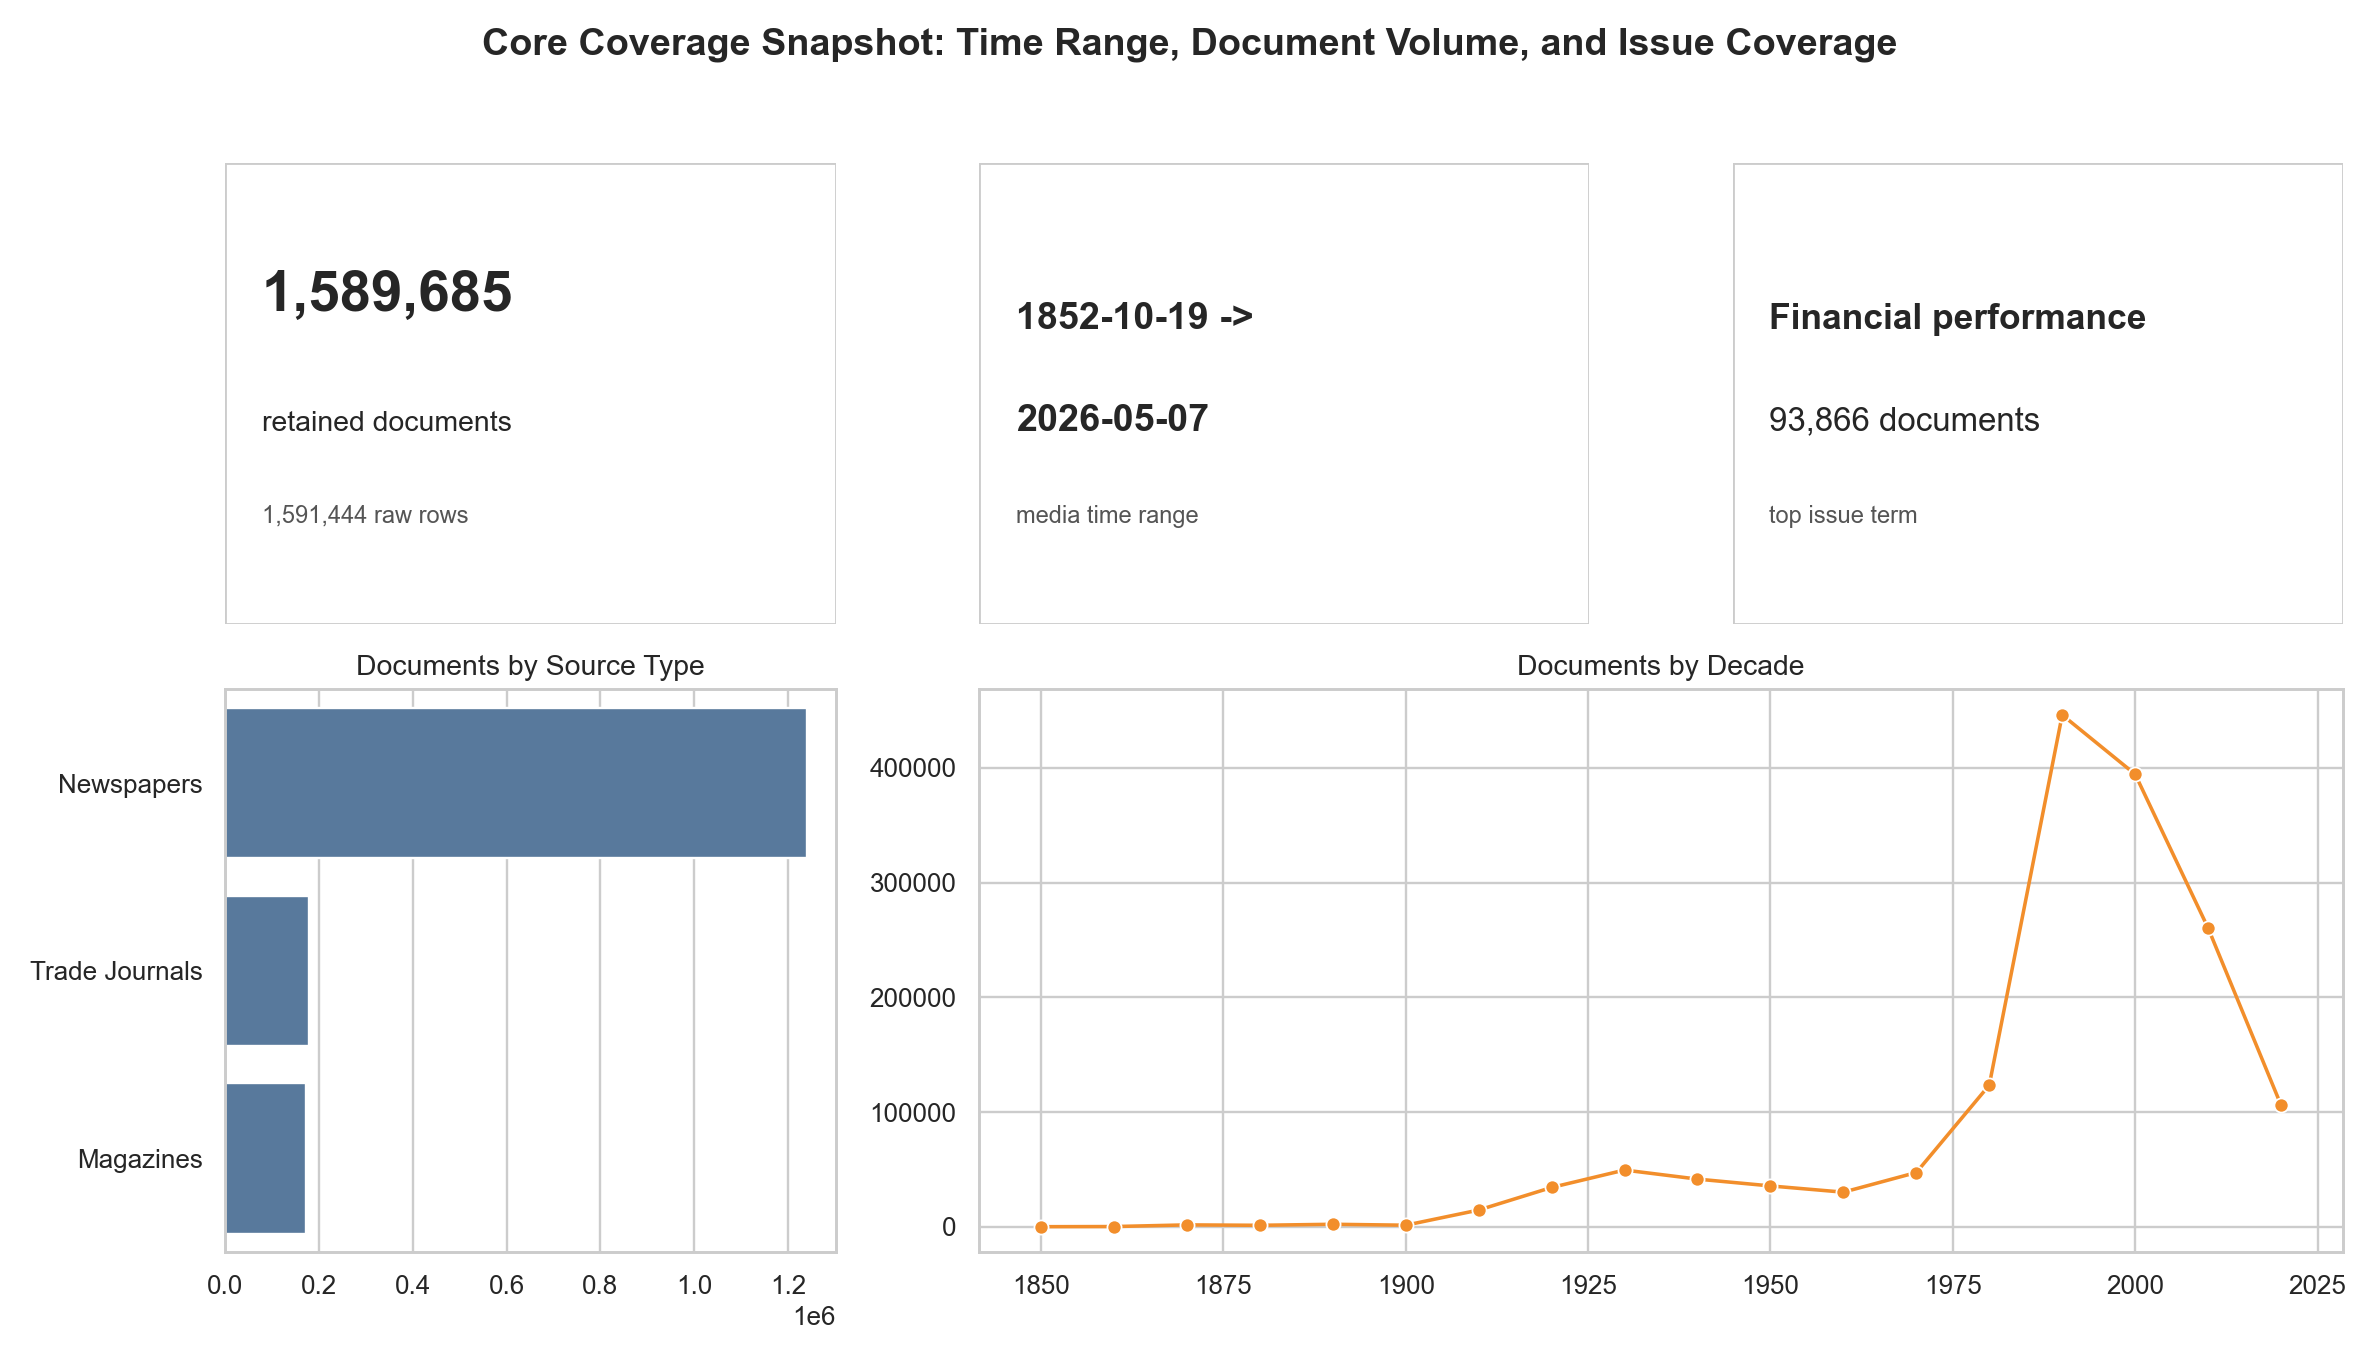

In [3]:
display(Image(filename=str(FIG / 'core_coverage_snapshot.png')))

## Metadata Field Audit

In [4]:
pd.read_csv(FINAL / 'metadata_field_audit.csv')

,question,answer,evidence
0,issue_or_volume_metadata_present,no,"No Issue, Volume, Issue Number, issue date, or comparable issue-enumeration field exists in extended.csv."
1,issue_topic_metadata_present,yes,"Subject Terms and Class Terms provide topical/issue categories, but not serial issue completeness."
2,can_assess_complete_issue_coverage,no,"Date, publication title, pages, and start page can show temporal/article density, but cannot prove all issues of a s..."
3,full_text_online_field_present,no,"No field containing full text, online availability, URL, document URL, or full-text availability is present in the c..."
4,full_text_available_in_current_export,no,The current files are metadata CSV exports only; article body text is absent.


## Final Cleaned Dataset

In [5]:
pd.read_json(FINAL / 'cleaned_metadata_summary.json', typ='series')

cleaned_rows                                                           1522625
deduplicated_rows                                                      1476060
duplicate_rows_removed                                                   46565
cleaned_parquet                 cleaned_metadata_english_north_america.parquet
cleaned_csv_zip                 cleaned_metadata_english_north_america.csv.zip
deduplicated_parquet      cleaned_metadata_english_north_america_dedup.parquet
deduplicated_csv_zip      cleaned_metadata_english_north_america_dedup.csv.zip
dtype: object

In [6]:
pd.read_csv(FINAL / 'cleaned_metadata_data_dictionary.csv')

,field,definition
0,goid,Original document identifier.
1,title,Article/document title.
2,date,Parsed document date in YYYY-MM-DD format.
3,year,Parsed publication year.
4,decade,Year rounded down to decade.
5,source_type,Original source type.
6,object_type,Original object type.
7,language,Original language value; final cleaned set keeps English only.
8,authors,Original authors metadata string.
9,publication_title_raw,Original publication title.


## Scope

In [7]:
pd.read_csv(OUT / 'publisher_region_counts.csv')

,Publisher Region,Documents
0,United States,1587194
1,Canada,2491


In [8]:
pd.read_csv(OUT / 'edition_flag_counts.csv')

,Edition Flag,Documents
0,main_or_unspecified,1514264
1,asian wall street journal,41668
2,wall street journal asia,28655
3,national post,2491
4,international herald tribune,2335
5,international new york times,272


In [9]:
pd.read_csv(OUT / 'excluded_media_summary.csv')

,Normalized Publication Title,Publication Title,Publisher City,Publisher Province,Publisher Region,Publisher Name,Edition Flag,Exclusion Reason,Documents
0,Nacla Report On Americas,NACLA Report on the Americas,"Abingdon, Oxfordshire",NaN,Non-North America,Taylor & Francis Ltd.,NaN,publisher appears outside North America,1703
1,Report On Americas,Report on the Americas,"Abingdon, Oxfordshire",NaN,Non-North America,Taylor & Francis Ltd.,NaN,publisher appears outside North America,56


## Media Coverage

In [10]:
pd.read_csv(OUT / 'media_summary.csv').head(20)

,Normalized Publication Title,Display Publication Title,Documents,First Date,Last Date,Raw Name Variants,Top Raw Names,Top Publisher Locations,Publisher Regions,Edition Flags,Top Publisher Names,Unique Authors,Top Authors,Top Subject Terms
0,New York Times,New York Times,470112,1857-09-17,2026-05-07,5,New York Times (1923-); New York Times; New York Times (1857-1922); The New York Times; New York Times (2008-),"New York, NY",United States,main_or_unspecified,New York Times Company; The New York Times Company,8691,"Bradsher, Keith; Silk, Leonard; Norris, Floyd; Smialek, Jeanna; Krugman, Paul; Quint, Michael; Hurtado, Robert; Gilp...",Finances; Financial performance; Economic Conditions And Trends; Economic conditions; International Trade And World ...
1,Wall Street Journal,Wall Street Journal,383625,1982-01-05,2026-05-07,2,Wall Street Journal; Wall Street Journal (2008-),"South Brunswick, NJ",United States,main_or_unspecified,Dow Jones & Company Inc.,10070,"Anonymous; Lahart, Justin; Timiraos, Nick; Ip, Greg; Browning, E S; Wessel, David; Hilsenrath, Jon; Talley, Karen",Financial performance; Investments; Stock exchanges; Company reports; Interest rates; Economic growth; Economic cond...
2,Commerce Business Daily,Commerce Business Daily,206492,1997-12-11,2002-01-04,1,Commerce Business Daily,"Washington, DC",United States,main_or_unspecified,"U.S. Dept. of Commerce, Office of Field Services",0,NaN,Civil engineering; Telecommunications systems; Small business; Dredging; Composite materials; Environmental protecti...
3,US News And World Report,U.S. News & World Report,85195,1981-06-22,2016-03-01,1,U.S. News & World Report,"Washington, DC",United States,main_or_unspecified,U.S. News and World Report,3988,"Anonymous; Walsh, Kenneth T; Reinberg, Steven; Stein, Lisa; Bedard, Paul; Kurtzleben, Danielle; Zuckerman, Mortimer ...",Presidents; Medical research; Candidates; Political parties; Presidential elections; Politics; Political campaigns; ...
4,Washington Post,Washington Post,83113,1987-01-08,2026-05-07,3,The Washington Post; The Washington Post (pre-1997 Fulltext); The Washington Post (2008-),"Washington, DC",United States,main_or_unspecified,WP Company LLC d/b/a The Washington Post; The Washington Post Company,5850,"Anonymous; Berry, John M; Singletary, Michelle; Pearlstein, Steven; Samuelson, Robert J; Irwin, Neil; Knight, Jerry;...",Economic conditions; Financial performance; Political finance; Economic policy; School finance; Company reports; Rec...
5,Portafolio,Portafolio,65670,2018-03-01,2025-04-30,1,Portafolio,"Miami, FL",United States,main_or_unspecified,GDA Media Inc.,2,Marola; Casa editorial El Tiempo,Covid-19; Coronaviruses; EU membership; El Nino; Paramilitary groups; Digital currencies; Impeachment; Nearshoring
6,Barrons,Barron's,63263,1921-05-09,2026-05-07,3,Barron's; Barron's (Online); Barron's (1921-1942),"South Brunswick, NJ",United States,main_or_unspecified,Dow Jones & Company Inc.,3139,"Forsyth, Randall W; Bary, Andrew; Anonymous; Norton, Leslie P; Epstein, Gene; Savitz, Eric J; Jasinski, Nicholas; St...",Investments; Investors; Stock prices; Stock exchanges; Securities markets; Interest rates; Stocks; Economic growth
7,Asian Wall Street Journal,Asian Wall Street Journal,41668,1991-06-02,2005-10-14,1,Asian Wall Street Journal,"South Brunswick, NJ",United States,asian wall street journal,Dow Jones & Company Inc.,928,"Anonymous; Ip, Greg; Sims, G Thomas; Areddy, James T; Browning, E S; Hilsenrath, Jon E; Lauricella, Tom; Sesit, Mich...",Economic growth; Gross Domestic Product--GDP; Interest rates; Stock exchanges; Investors; Investments; Economists; C...
8,Business Week,Business Week,28754,2002-01-02,2010-01-29,1,Business Week (Online),"New York, NY",United States,main_or_unspecified,Bloomberg Finance LP,1435,"Anonymous; Kharif, Olga; Steverman, Ben; Hesseldahl, Arik; Klein, Karen E; Bogoslaw, David; Holahan, Catherine; Pete...",Investments; Investors; Stock exchanges; Earnings per share; Stock prices; Corporate p

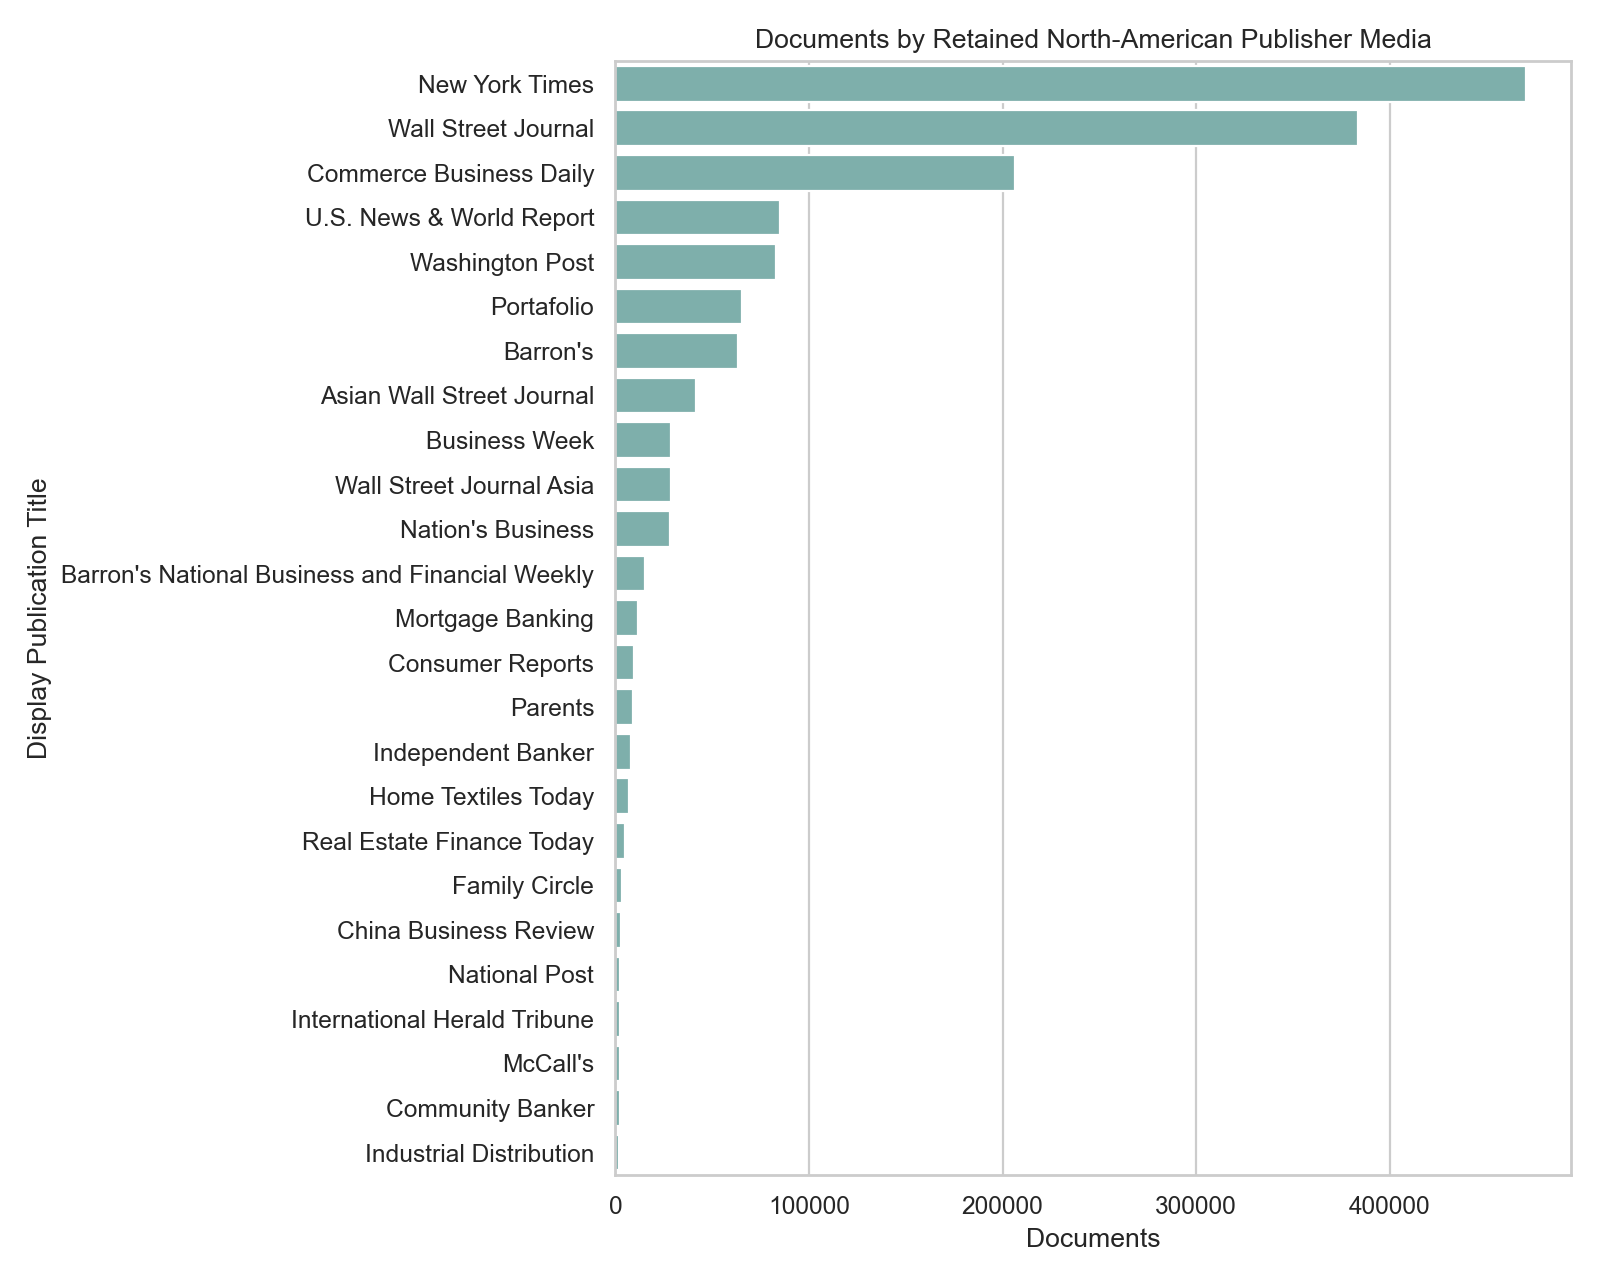

In [11]:
display(Image(filename=str(FIG / 'media_summary_counts.png')))

## Time Coverage

In [12]:
pd.read_csv(OUT / 'decade_counts.csv')

,Decade,Documents
0,1850,31
1,1860,159
2,1870,1607
3,1880,1250
4,1890,2147
5,1900,1325
6,1910,14547
7,1920,34228
8,1930,49423
9,1940,41519


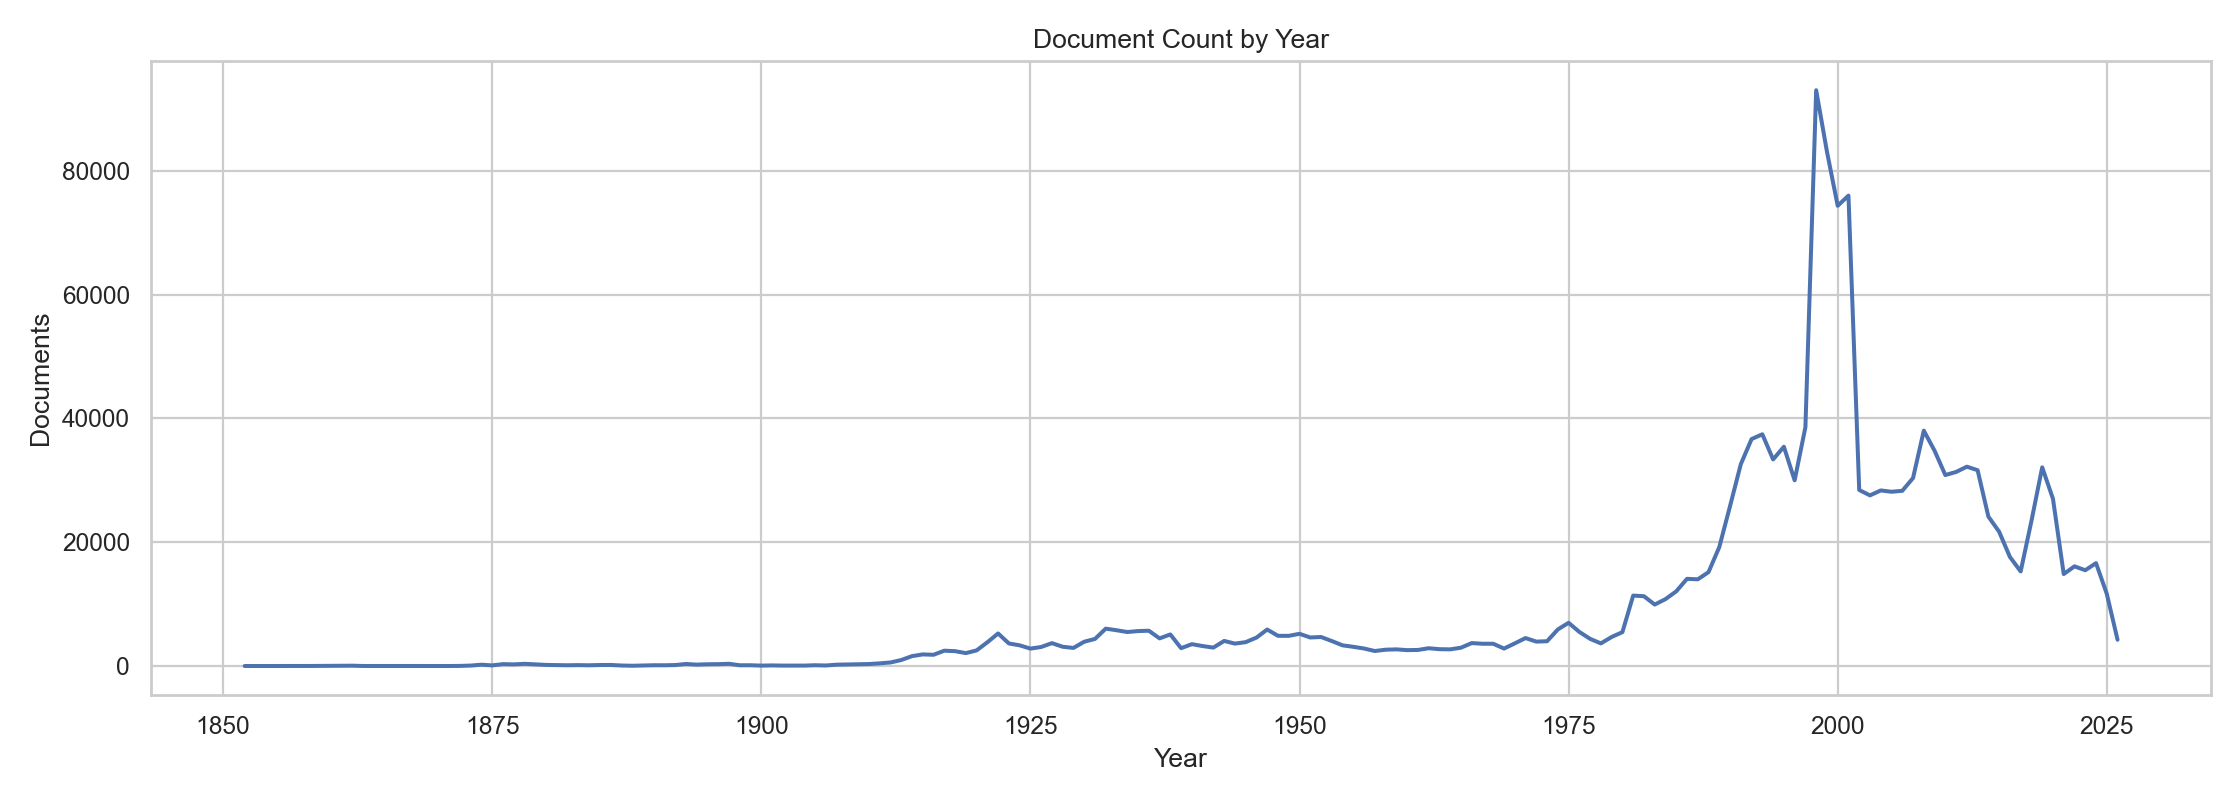

In [13]:
display(Image(filename=str(FIG / 'documents_by_year.png')))

## Source Type Over Time

In [14]:
pd.read_csv(OUT / 'source_type_by_year_english_na.csv').head(20)

,year,source_type,documents
0,1852,Newspapers,1
1,1856,Newspapers,1
2,1857,Newspapers,1
3,1858,Newspapers,8
4,1859,Newspapers,20
5,1860,Newspapers,17
6,1861,Newspapers,32
7,1862,Newspapers,54
8,1863,Newspapers,6
9,1864,Newspapers,5


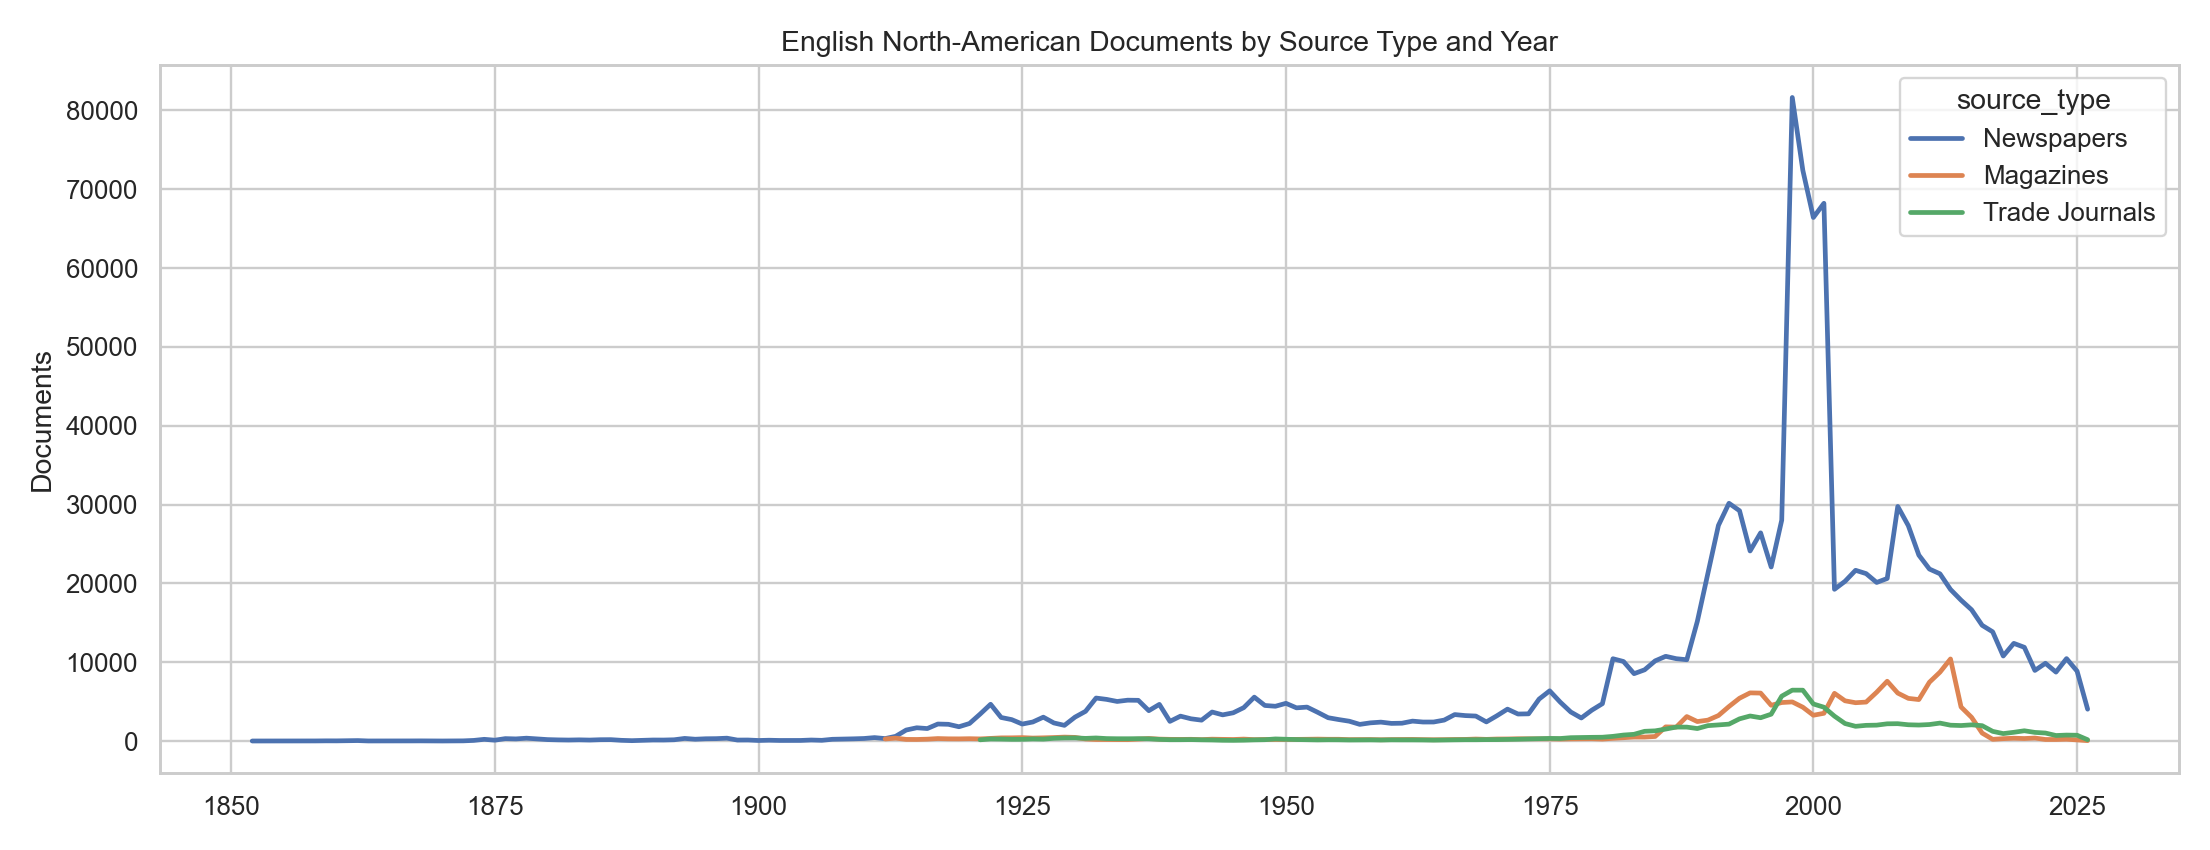

In [15]:
display(Image(filename=str(FIG / 'source_type_by_year_lines.png')))

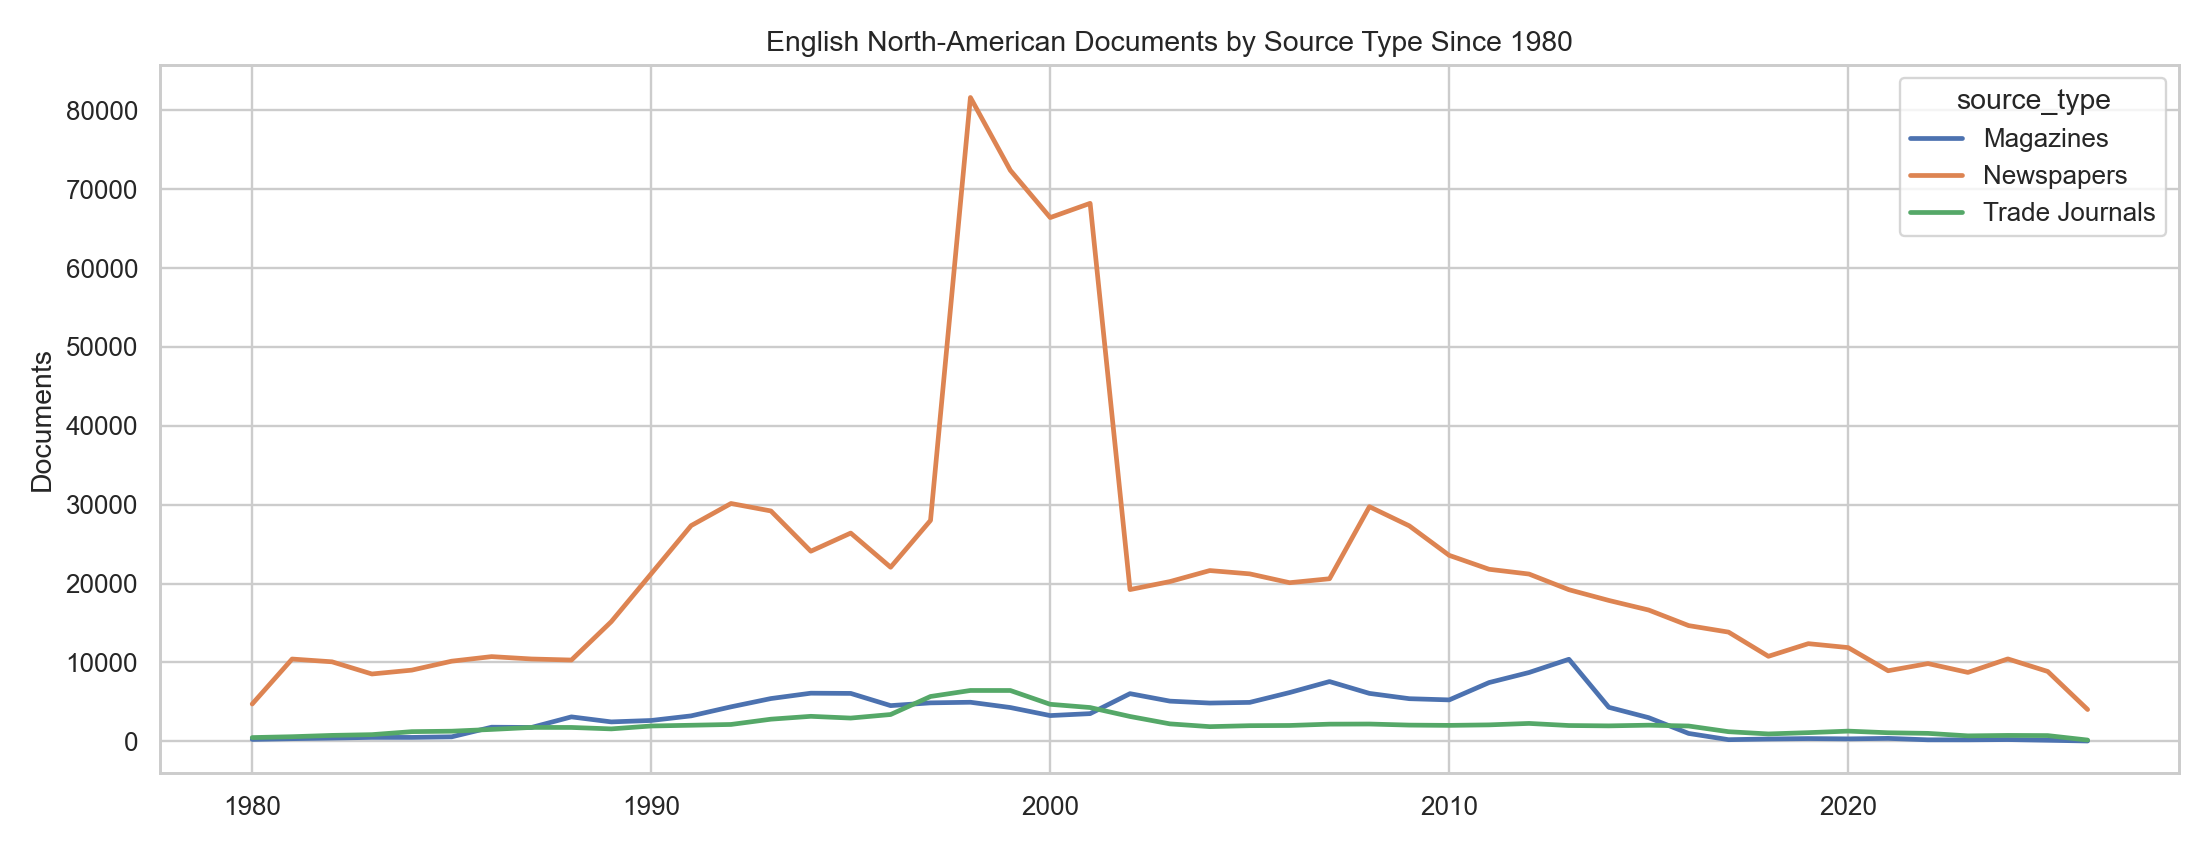

In [16]:
display(Image(filename=str(FIG / 'source_type_by_year_since_1980.png')))

## Issue Coverage

In [17]:
pd.read_csv(OUT / 'core_issue_coverage.csv')

,Subject Term,Documents
0,Financial performance,93866
1,Investments,79108
2,Interest rates,73443
3,Stock exchanges,70832
4,Economic conditions,69790
5,Economic growth,63435
6,Company reports,57723
7,Stock prices,54910
8,Gross Domestic Product--GDP,46754
9,Securities markets,45714


In [18]:
pd.read_csv(OUT / 'top_subject_terms.csv').head(20)

,Subject Term,Documents
0,Financial performance,93866
1,Investments,79108
2,Interest rates,73443
3,Stock exchanges,70832
4,Economic conditions,69790
5,Economic growth,63435
6,Company reports,57723
7,Stock prices,54910
8,Gross Domestic Product--GDP,46754
9,Securities markets,45714


In [19]:
pd.read_csv(OUT / 'top_class_terms.csv').head(15)

,Class Term,Documents
0,United States,122189
1,Securities and Commodity Exchanges,72042
2,Investment analysis & personal finance,65244
3,Monetary Authorities-Central Bank,52972
4,Portfolio Management and Investment Advice,47136
5,Executive Offices,37395
6,Other Financial Vehicles,34631
7,Open-End Investment Funds,26965
8,Public Finance Activities,26063
9,Us,23543


## Data Quality

In [20]:
pd.read_csv(OUT / 'duplicate_summary.csv')

,metric,value
0,retained_rows,1589685
1,raw_rows,1591444
2,excluded_rows,1759
3,duplicate_goid_rows,0
4,same_title_date_media_duplicate_rows,46804
5,same_title_date_duplicate_rows,54528
6,invalid_or_missing_date_rows,0


In [21]:
pd.read_csv(OUT / 'column_completeness.csv')

,Column,Missing Rows,Missing Share,Observed Rows
0,Company Name,1146331,0.721106,443354
1,Class Terms,1122882,0.706355,466803
2,Authors,893597,0.562122,696088
3,Pages,590021,0.371156,999664
4,Subject Terms,562069,0.353573,1027616
5,Publisher Province,240,0.000151,1589445
6,Title,24,0.000015,1589661
7,Date,0,0.000000,1589685
8,Publisher City,0,0.000000,1589685
9,Publication Title,0,0.000000,1589685


In [22]:
pd.read_csv(OUT / 'publisher_city_counts.csv').head(20)

,Publisher City,Documents
0,South Brunswick,532643
1,New York,517356
2,Washington,443662
3,Miami,65670
4,Yonkers,9793
5,Minneapolis,7208
6,Des Moines,3579
7,Toronto,2491
8,Rockaway,1854
9,Birmingham,1536


In [23]:
pd.read_csv(OUT / 'publisher_city_raw_counts.csv').head(20)

,Publisher City Raw,Documents
0,South Brunswick,532643
1,NEW YORK,504075
2,WASHINGTON,301783
3,Washington,141783
4,Miami,65670
5,New York,13137
6,Yonkers,9793
7,Minneapolis,7208
8,Des Moines,3579
9,Toronto,2491


## Title Topic Modeling

In [24]:
pd.read_json(OUT / 'topic_model_profile.json', typ='series')

topics                                                  12
documents                                           100000
features                                              6000
source_scope       cleaned English North-American metadata
language_filter                                    English
dtype: object

In [25]:
pd.read_csv(OUT / 'topic_counts.csv')

,Topic,Sample Documents,Topic Label
0,9,10938,"services, support, repair, maintenance, air"
1,10,10926,"market, economy, stocks, prices, oil"
2,0,10815,"business, small, state, aid, year"
3,11,9707,"budget, plan, tax, house, health"
4,2,9032,"profit, sales, quarter, net, earnings"
5,8,8135,"world, bank, europe, china, technology"
6,7,7934,"new, big, crisis, debt, loan"
7,6,7477,"funds, fund, industry, group, company"
8,4,6527,"economic, rate, home, amp, real"
9,1,6428,"street, city, wall, high, wall street"


In [26]:
pd.read_csv(OUT / 'topic_terms.csv').query('Rank <= 8')

,Topic,Rank,Term,Weight,Topic Label
0,0,1,business,2669.918969,"business, small, state, aid, year"
1,0,2,small,802.598907,"business, small, state, aid, year"
2,0,3,state,639.468381,"business, small, state, aid, year"
3,0,4,aid,617.122681,"business, small, state, aid, year"
4,0,5,year,555.464333,"business, small, state, aid, year"
...,...,...,...,...,...
168,11,4,house,704.083328,"budget, plan, tax, house, health"
169,11,5,health,566.914339,"budget, plan, tax, house, health"
170,11,6,ahead,530.600427,"budget, plan, tax, house, health"
171,11,7,cuts,437.270406,"budget, plan, tax, house, health"


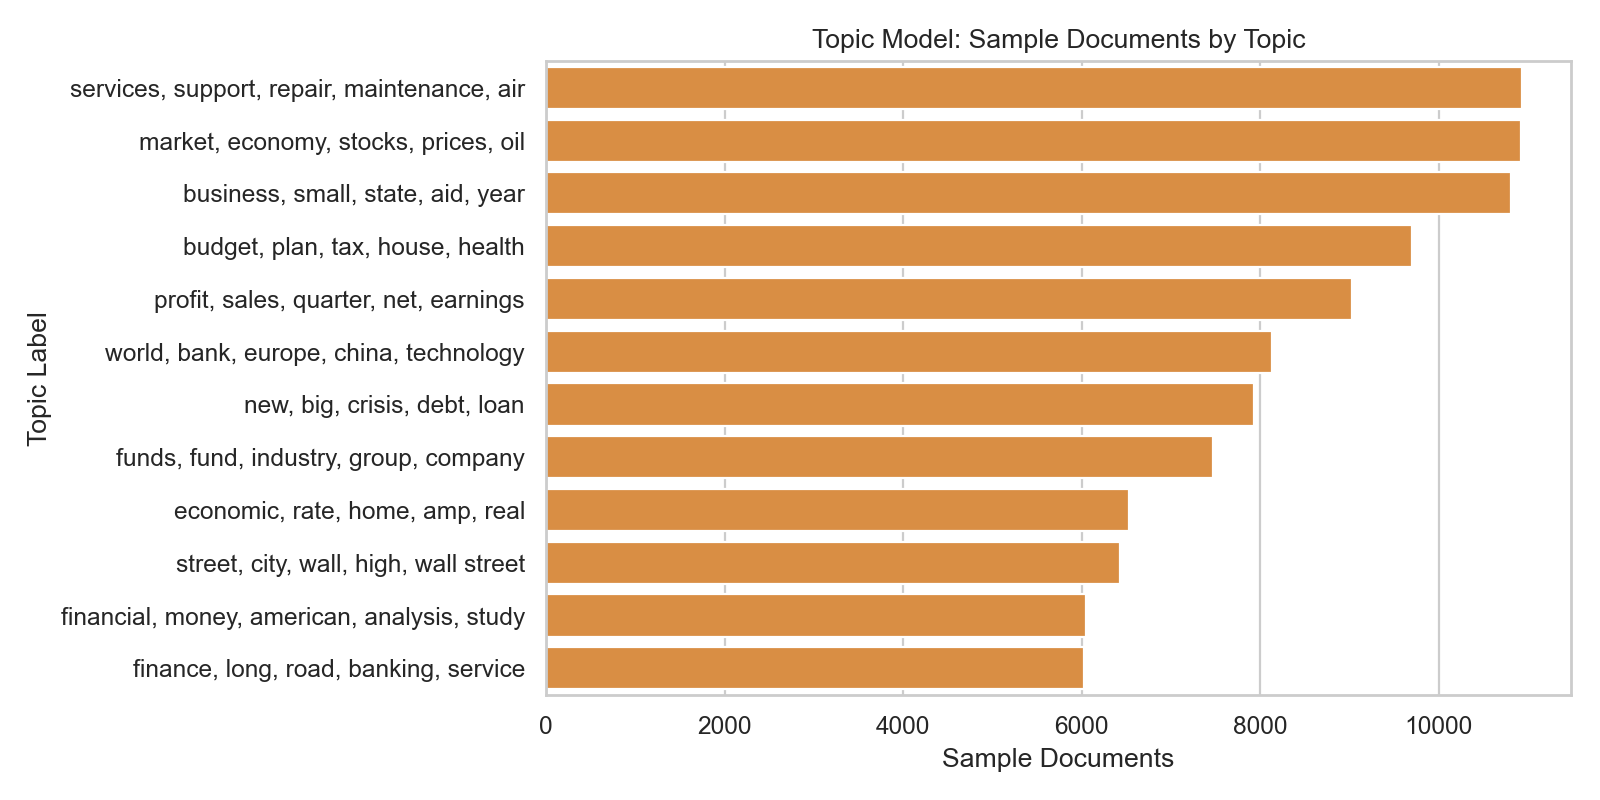

In [27]:
display(Image(filename=str(FIG / 'topic_counts.png')))

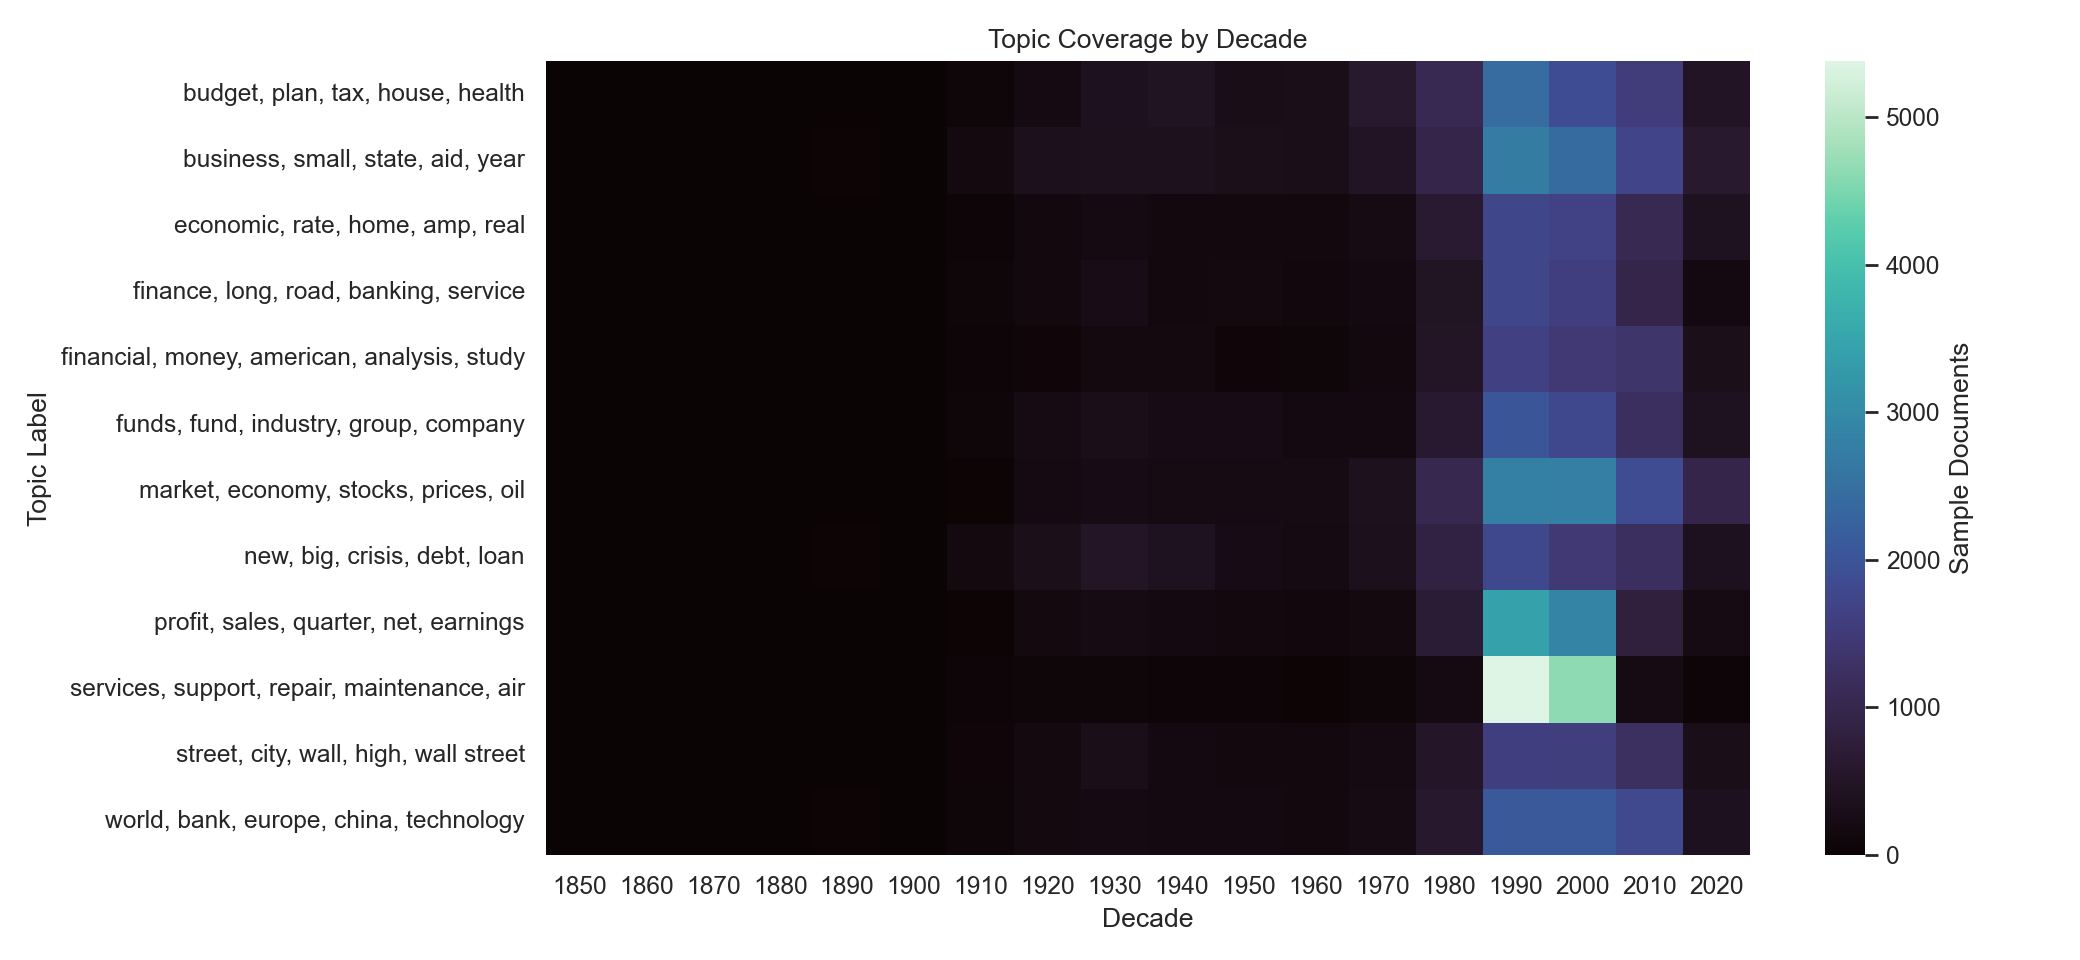

In [28]:
display(Image(filename=str(FIG / 'topic_by_decade_heatmap.png')))

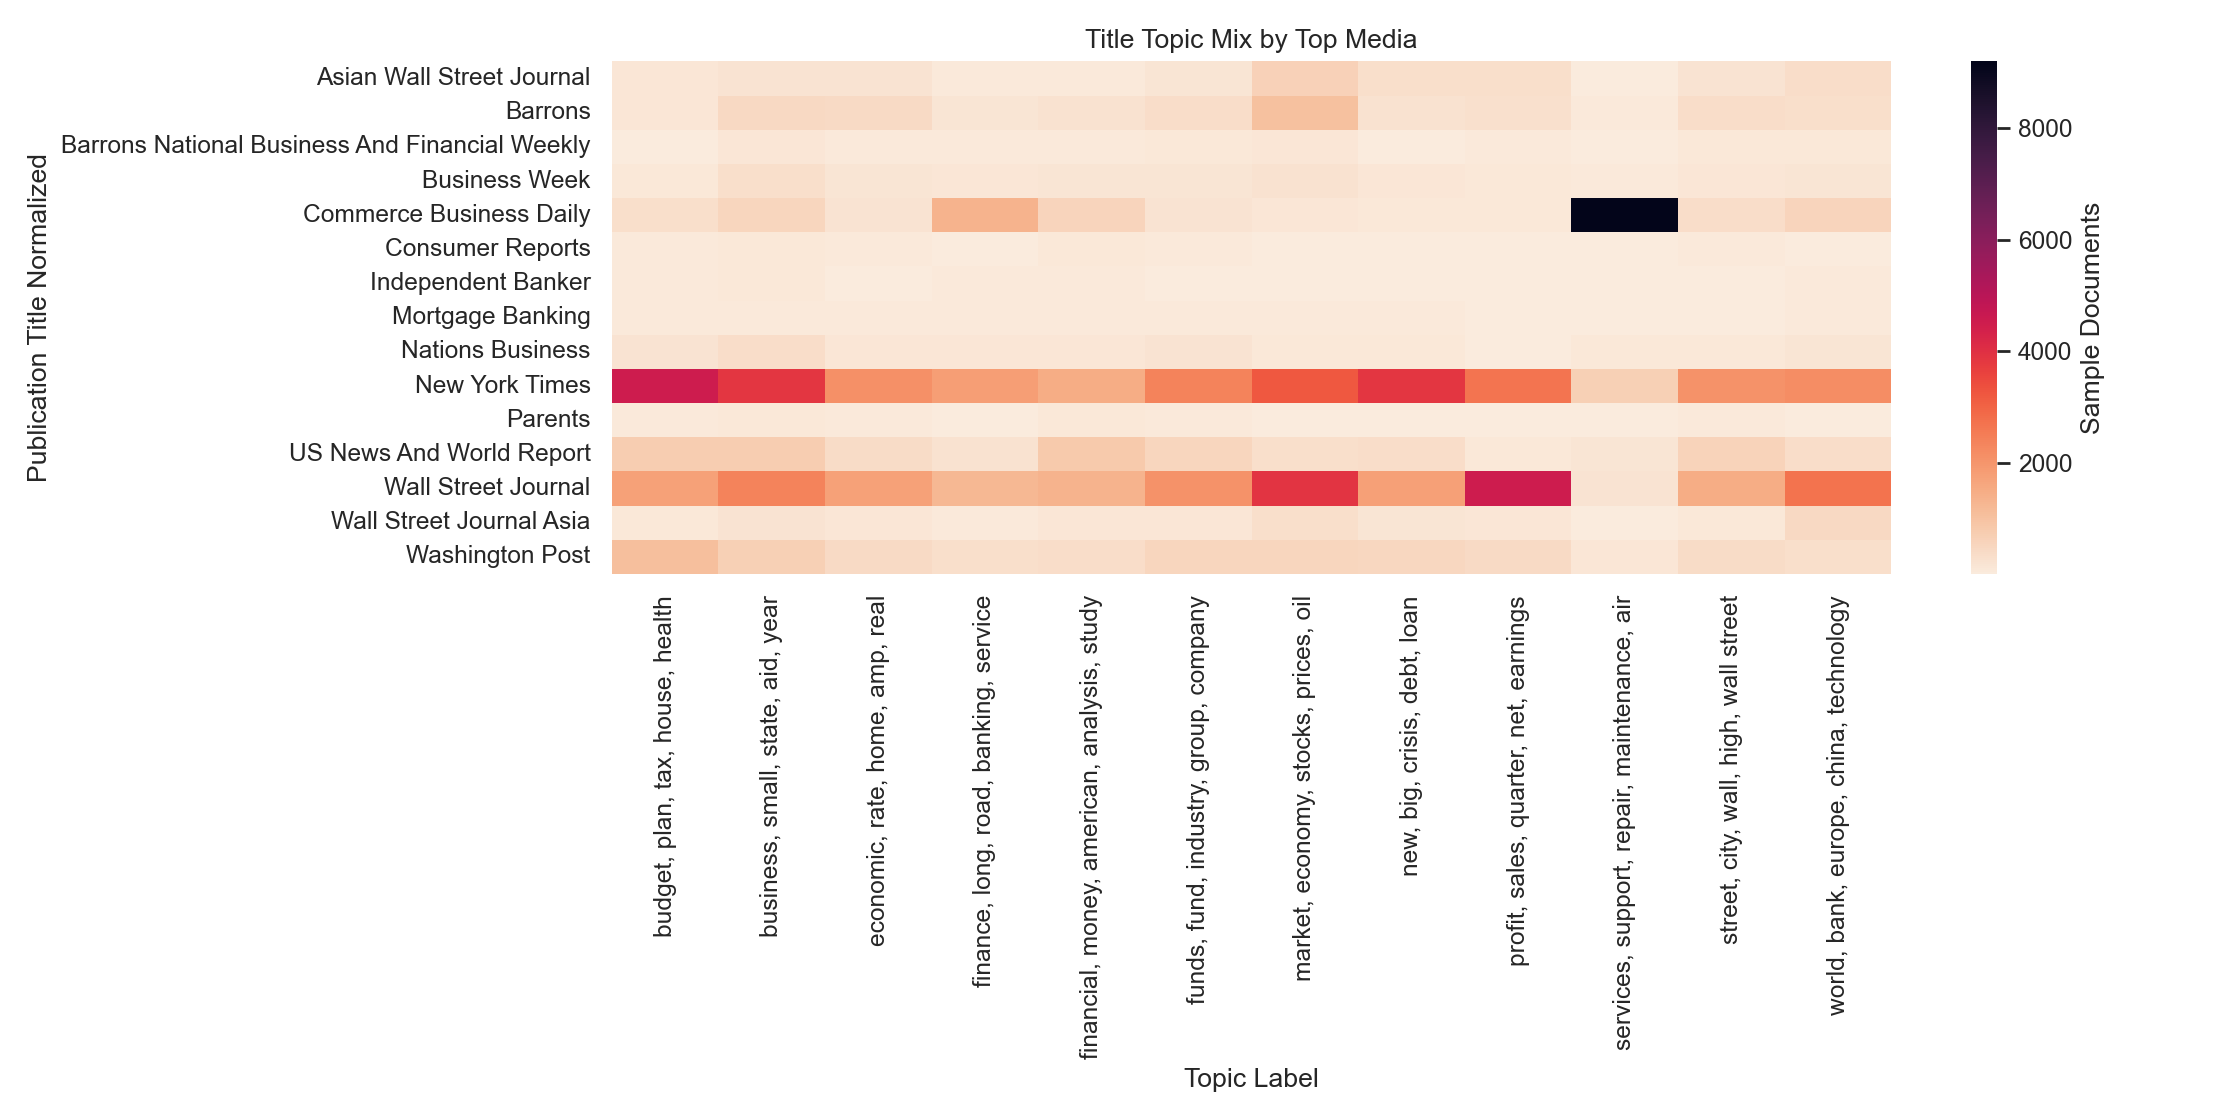

In [29]:
display(Image(filename=str(FIG / 'topic_by_media_heatmap.png')))